In [1]:
import json
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
import os
import pickle
from sklearn.feature_extraction.text import CountVectorizer

import warnings

warnings.filterwarnings("ignore")

# For embeddings and similarity computation
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity

    print("Required libraries imported successfully!")
except ImportError as e:
    print(f"Missing library: {e}")
    print(
        "Please install with: pip install sentence-transformers scikit-learn networkx"
    )

Missing library: No module named 'sentence_transformers'
Please install with: pip install sentence-transformers scikit-learn networkx


In [2]:
def load_corpus(file_path: str) -> dict[str, dict]:
    """
    TODO

    Load corpus data from JSONL file.
    Returns dictionary mapping document IDs to document data.
    """
    corpus = {}
    with open(file_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            line = line.strip()
            obj = json.loads(line)
            docid = str(obj["_id"])
            corpus[docid] = obj
    return corpus


def load_queries(file_path: str) -> dict[str, dict]:
    """
    TODO

    Load query data from JSONL file.
    Returns dictionary mapping query IDs to query data.
    """
    queries = {}
    with open(file_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            line = line.strip()
            obj = json.loads(line)
            qid = str(obj["_id"])
            queries[qid] = obj
    return queries


def load_qrels(file_path: str) -> dict[str, dict[str, int]]:
    """
    TODO

    Load relevance judgments from TSV file.
    Returns dictionary mapping query IDs to candidate relevance scores.
    """
    qrels = defaultdict(dict)
    with open(file_path, "r") as f:
        lines = f.readlines()
        for line in lines[1:]:
            qid, docid, score = line.strip().split("\t")
            qrels[qid][docid] = int(score)
    return qrels


print("Loading dataset...")
corpus = load_corpus('./data/corpus.jsonl')
queries = load_queries('./data/queries.jsonl')
qrels_valid = load_qrels('./data/valid.tsv')


print(f"Loaded {len(corpus)} documents in corpus")
print(f"Loaded {len(queries)} queries")
print(f"Loaded relevance for {len(qrels_valid)} queries (dataset)")

Loading dataset...
Loaded 25657 documents in corpus
Loaded 1000 queries
Loaded relevance for 700 queries (dataset)


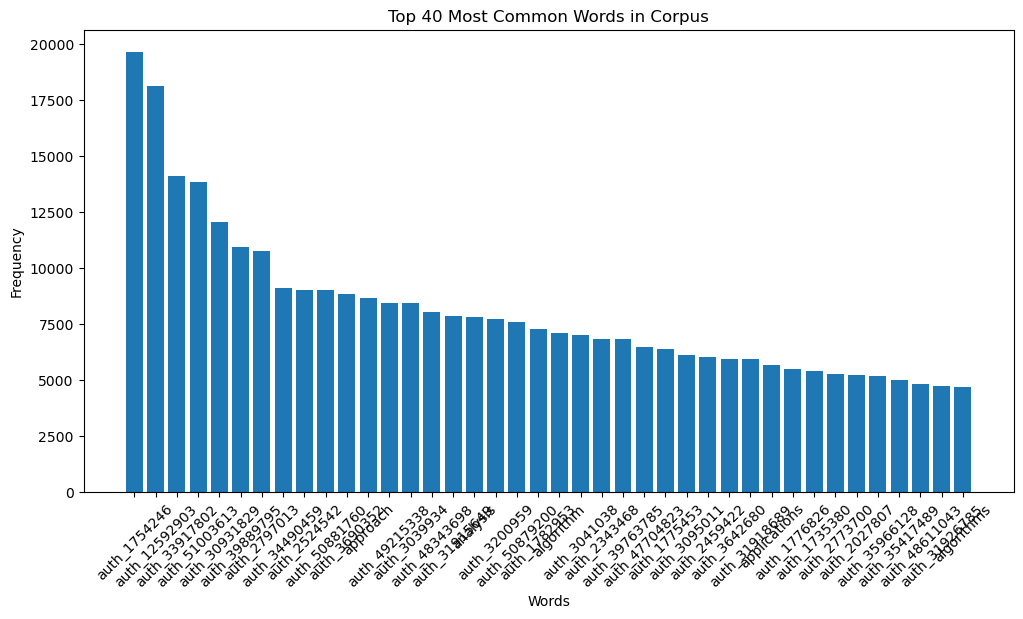

In [7]:
def plot_word_distribution(term_document_matrix: np.ndarray, top_n: int = 20):
    """
    Plot the distribution of the most common words in the corpus.
    """
    import matplotlib.pyplot as plt

    word_counts = np.sum(term_document_matrix, axis=0)
    terms = vectorizer.get_feature_names_out()
    word_count_dict = dict(zip(terms, word_counts))
    most_common_words = Counter(word_count_dict).most_common(top_n)
    words, counts = zip(*most_common_words)
    
    plt.figure(figsize=(12, 6))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(f'Top {top_n} Most Common Words in Corpus')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.show()

plot_word_distribution(term_document_matrix, top_n=40)

In [3]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 1. CONFIGURATION DES POIDS (Ajustables)
# ==========================================
MY_WEIGHTS = {
    "title": 1,        # Importance du titre
    "text": 1,         # Base (texte du résumé)
    "authors": 10,     # Importance d'un auteur commun
    "references": 10,  # Importance d'une référence commune
    "cited_by": 1,    # Importance d'une citation commune
    "year": 1          # Importance de l'année
}

# ==========================================
# 2. FONCTIONS DE PRÉPARATION (TEXT ENRICHMENT)
# ==========================================
def get_weighted_text(doc_data, weights):
    """Transforme un dictionnaire (doc ou query) en texte pondéré."""
    metadata = doc_data.get('metadata', {})
    
    # Préparation des segments avec répétition selon les poids
    # On ajoute un espace final pour éviter la fusion de mots
    t = (str(doc_data.get('title', '')) + " ") * weights.get('title', 1)
    txt = (str(doc_data.get('text', '')) + " ") * weights.get('text', 1)
    
    # Métadonnées avec préfixes pour éviter les collisions avec le texte
    auths = " ".join([f"AUTH_{a}" for a in metadata.get('authors', [])])
    auth_tokens = (auths + " ") * weights.get('authors', 1)
    
    refs = " ".join([f"REF_{r}" for r in metadata.get('references', [])])
    ref_tokens = (refs + " ") * weights.get('references', 1)
    
    cites = " ".join([f"CITE_{c}" for c in metadata.get('cited_by', [])])
    cite_tokens = (cites + " ") * weights.get('cited_by', 1)
    
    y_val = metadata.get('year', '')
    year_token = (f"YEAR_{y_val} " if y_val else "") * weights.get('year', 1)
    
    return f"{t}{txt}{auth_tokens}{ref_tokens}{cite_tokens}{year_token}".strip()

# ==========================================
# 3. CRÉATION DE LA MATRICE
# ==========================================
def build_vectorizer_and_matrix(corpus, weights):
    """Initialise le vectorizer et crée la matrice TF-IDF enrichie."""
    # Pattern crucial : autorise les underscores et les chiffres pour nos tags
    custom_pattern = r'\b\w{2,}\b|AUTH_\w+|CITE_\w+|REF_\w+|YEAR_\w+'
    
    vectorizer = TfidfVectorizer(
        token_pattern=custom_pattern,
        max_df=1.0,  # Ne filtre pas les dates même si très fréquentes
        min_df=1     # Ne filtre pas les auteurs même si uniques
    )
    
    # Transformation de tout le corpus en super-textes
    enriched_docs = [get_weighted_text(doc, weights) for doc in corpus.values()]
    
    # Apprentissage du vocabulaire et création de la matrice
    matrix = vectorizer.fit_transform(enriched_docs)
    
    return vectorizer, matrix

# ==========================================
# 4. MOTEUR DE RECHERCHE
# ==========================================
def first_search_engine(query_obj, corpus_subset, matrix_subset, vectorizer, weights, top_k=5):
    """Recherche dans un sous-ensemble (candidats) avec les mêmes poids."""
    # 1. On transforme la requête avec EXACTEMENT la même logique de poids
    full_query = get_weighted_text(query_obj, weights)
    
    # 2. Vectorisation (transform uniquement, ne pas refaire de fit)
    query_vec = vectorizer.transform([full_query])
    
    # 3. Similarité Cosinus
    similarities = cosine_similarity(query_vec, matrix_subset)[0]
    
    # 4. Tri des résultats
    corpus_ids = list(corpus_subset.keys())
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    return [(corpus_ids[i], similarities[i]) for i in top_indices]

# ==========================================
# 5. ÉVALUATION
# ==========================================
def evaluate_enriched_engine(qrels_valid, queries, corpus, vectorizer, full_matrix, weights):
    """Évalue les performances (Precision, Recall, F1)."""
    total_tp, total_fn, total_fp = 0, 0, 0
    corpus_ids = list(corpus.keys())

    for q_id, target_docs in qrels_valid.items():
        if q_id not in queries: continue
        
        # Isolation des 30-100 candidats du valid.tsv pour cette requête
        relevant_indices = [corpus_ids.index(d_id) for d_id in target_docs if d_id in corpus]
        restricted_corpus = {d_id: corpus[d_id] for d_id in target_docs if d_id in corpus}
        restricted_matrix = full_matrix[relevant_indices]
        
        # Exécution de la recherche
        results = first_search_engine(queries[q_id], restricted_corpus, restricted_matrix, vectorizer, weights, top_k=5)
        
        # Comptage des succès (hits)
        hits = sum(1 for d_id, score in results if target_docs.get(d_id, 0) == 1)
        total_relevant = sum(target_docs.values())
        
        total_tp += hits
        total_fn += (total_relevant - hits)
        total_fp += (len(results) - hits)

    # Métriques finales
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n--- RÉSULTATS (Poids: {weights}) ---")
    print(f"Rappel: {recall:.4f} | Précision: {precision:.4f} | F1-Score: {f1:.4f}")
    return f1

# ==========================================
# 6. LANCEMENT
# ==========================================

# A. Création de la matrice (à refaire si tu changes les poids)
vectorizer, enriched_matrix = build_vectorizer_and_matrix(corpus, MY_WEIGHTS)

# B. Lancement de l'évaluation
score = evaluate_enriched_engine(
    qrels_valid, 
    queries, 
    corpus, 
    vectorizer, 
    enriched_matrix, 
    MY_WEIGHTS
)


--- RÉSULTATS (Poids: {'title': 1, 'text': 1, 'authors': 10, 'references': 10, 'cited_by': 1, 'year': 1}) ---
Rappel: 0.6988 | Précision: 0.6889 | F1-Score: 0.6938


In [4]:
import numpy as np
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 1. CONFIGURATION DES POIDS
# ==========================================
MY_WEIGHTS = {
    "title": 1,
    "text": 1,
    "authors": 10,
    "references": 10,
    "cited_by": 1,
    "year": 1 
}

# ==========================================
# 2. FONCTION DE PONDÉRATION
# ==========================================
def get_weighted_text(doc_data, weights):
    metadata = doc_data.get('metadata', {})
    t = (str(doc_data.get('title', '')) + " ") * weights.get('title', 1)
    txt = (str(doc_data.get('text', '')) + " ") * weights.get('text', 1)
    
    auths = " ".join([f"AUTH_{a}" for a in metadata.get('authors', [])])
    auth_tokens = (auths + " ") * weights.get('authors', 1)
    
    refs = " ".join([f"REF_{r}" for r in metadata.get('references', [])])
    ref_tokens = (refs + " ") * weights.get('references', 1)
    
    cites = " ".join([f"CITE_{c}" for c in metadata.get('cited_by', [])])
    cite_tokens = (cites + " ") * weights.get('cited_by', 1)
    
    y_val = metadata.get('year', '')
    year_token = (f"YEAR_{y_val} " if y_val else "") * weights.get('year', 1)
    
    return f"{t}{txt}{auth_tokens}{ref_tokens}{cite_tokens}{year_token}".strip()

# ==========================================
# 3. CRÉATION DE LA MATRICE AVEC FILTRAGE
# ==========================================
def build_vectorizer_and_matrix(corpus, weights):
    custom_pattern = r'\b\w{2,}\b|AUTH_\w+|CITE_\w+|REF_\w+|YEAR_\w+'
    
    # --- Étape A : Génération des textes ---
    enriched_docs = [get_weighted_text(doc, weights) for doc in corpus.values()]
    
    # --- Étape B : Identification des 7 mots les plus fréquents ---
    # On utilise le même pattern que le vectorizer pour être cohérent
    all_tokens = []
    for doc in enriched_docs:
        all_tokens.extend(re.findall(custom_pattern, doc.lower()))
    
    counts = Counter(all_tokens)
    top_7_words = [word for word, freq in counts.most_common(7)]
    print(f"Mots les plus fréquents retirés : {top_7_words}")
    
    # --- Étape C : Initialisation avec filtres ---
    # min_df=2 retire automatiquement tous les mots qui n'apparaissent que dans 1 doc
    vectorizer = TfidfVectorizer(
        token_pattern=custom_pattern,
        stop_words=top_7_words, # Retire les 7 plus fréquents
        min_df=2,               # Retire les mots apparaissant 1 seule fois
        max_df=1.0              # On laisse max_df à 1.0 car on a déjà géré le top 7
    )
    
    matrix = vectorizer.fit_transform(enriched_docs)
    return vectorizer, matrix

# ==========================================
# 4. MOTEUR DE RECHERCHE & ÉVALUATION
# ==========================================
def first_search_engine(query_obj, corpus_subset, matrix_subset, vectorizer, weights, top_k=5):
    full_query = get_weighted_text(query_obj, weights)
    query_vec = vectorizer.transform([full_query])
    similarities = cosine_similarity(query_vec, matrix_subset)[0]
    
    corpus_ids = list(corpus_subset.keys())
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    return [(corpus_ids[i], similarities[i]) for i in top_indices]

def evaluate_enriched_engine(qrels_valid, queries, corpus, vectorizer, full_matrix, weights):
    total_tp, total_fn, total_fp = 0, 0, 0
    corpus_ids = list(corpus.keys())

    for q_id, target_docs in qrels_valid.items():
        if q_id not in queries: continue
        
        relevant_indices = [corpus_ids.index(d_id) for d_id in target_docs if d_id in corpus]
        restricted_corpus = {d_id: corpus[d_id] for d_id in target_docs if d_id in corpus}
        restricted_matrix = full_matrix[relevant_indices]
        
        results = first_search_engine(queries[q_id], restricted_corpus, restricted_matrix, vectorizer, weights, top_k=5)
        
        hits = sum(1 for d_id, score in results if target_docs.get(d_id, 0) == 1)
        total_relevant = sum(target_docs.values())
        
        total_tp += hits
        total_fn += (total_relevant - hits)
        total_fp += (len(results) - hits)

    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Rappel: {recall:.4f} | Précision: {precision:.4f} | F1-Score: {f1:.4f}")
    return f1

# ==========================================
# 5. EXÉCUTION
# ==========================================
# Recalcul de tout avec les nouveaux filtres
vectorizer, enriched_matrix = build_vectorizer_and_matrix(corpus, MY_WEIGHTS)

evaluate_enriched_engine(
    qrels_valid, 
    queries, 
    corpus, 
    vectorizer, 
    enriched_matrix, 
    MY_WEIGHTS
)

Mots les plus fréquents retirés : ['the', 'of', 'and', 'to', 'in', 'for', 'is']
Rappel: 0.6757 | Précision: 0.6660 | F1-Score: 0.6708


0.6707913669064749